# Analyzing Market Housing Prices and Crime in Los Angeles

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ `X` ] YES - make available
* [     ] NO - keep private

# Names

- Elvin Chen
- Jeremy Cho
- Vincent Cho
- Nahaby Piceno

# Abstract

This project focuses on the relationship between the crime severity and crime rates in an area to the mean housing prices in an area; How do factors such as the rate of crime or severity of crime influence the average market value of houses in Los Angeles county in 2023? From our background work, we concluded that there is a correlation between the crime and housing prices, however, the correlation between the two was rather weak, and other factors attributed more to housing prices. Our hypothesis is that there is a correlation between these two because if a crime took place in an area, the area would be looked at as more unsafe, and therefore the house price in the area would fall due to a perceived more dangerous environment.

We collected data from the LAPD and Zillow to prepare datasets for analyzing. We cleaned and merged the datasets from the LAPD and Zillow and gathered the zipcodes for all the crime found in the LAPD dataset. Through transforming, normalizing and filtering our data, we created a model to help predict housing prices based on the total crime and total crime severity in an area. Through our model, we deduced that crime is a bad predictor of housing prices and therefore needed more features to create a more accurate model. Overall, while our data was expansive, we found that crime was not the best indicator of housing price, and failed to support our hypothesis.

# Research Question

How do factors such as the rate of crime or severity of crime influence the average market value of houses in Los Angeles county in 2023? We plan to find summary measurements of crime for each ZIP code available in Los Angeles, and we plan to compare this data to the average value of homes in each ZIP code and explore the relationship between the two.

## Background and Prior Work

The cost of living in a particular area is influenced by many factors, the biggest of which is the cost of rent or the price of buying a house. This cost can be significantly influenced by the crime occurring in a particular neighborhood or area. The severity or frequency of crime can cause housing prices to fluctuate, which can be analyzed through a dataset of crime in the area. Understanding and visualizing the correlations between these factors is crucial for many people living in urban environments.

When looking at previous research regarding crime rates and housing prices, we can see a negative correlation, as described in the article Do Crime Hot Spots Affect Housing Prices? The authors, Ceccato and Wilhelmsson, utilized previous research in Sweden to determine a correlation in Stockholm. In their study, they sought to answer two hypotheses: the impact of crime on the prices of flats and single-family houses and whether the impact of crime varies by severity and housing type. This means they primarily examined domestic or local crime, such as vandalism, rather than theft or violent crimes like homicides or man-slaughter.

Their conclusions showed that the prices of flats and single-family houses were heavily discounted if they were near a crime hot spot. If a house was more than a kilometer away from the hot spot, its price increased by approximately 3,000 SEK. Additionally, they determined that vandalism was the crime that most heavily impacted housing prices. Although this analysis is highly relevant to our own, there are some key differences. The most significant is that our study focuses on Los Angeles rather than Stockholm, Sweden. This means that American laws and perceptions of crime severity might differ. Furthermore, we are analyzing the severity of crimes and their effect on housing prices. Since Sweden has lower crime rates on average compared to Los Angeles, we are also investigating whether a higher crime density affects housing prices differently.

Another article, How Crime Impacts Home Values in Your Neighborhood, presented similar findings, stating that higher crime rates lead to lower home prices. This is due to perceived instability, where the perception of safety is shattered in these neighborhoods. Additionally, the article discusses crimes occurring within the home, such as burglary, motor vehicle theft, and larceny, which are some of the most pressing concerns when it comes to housing price fluctuations. While this article is insightful, the author does not cite specific studies to support the claims. Moreover, the article is framed as a buyer’s guide rather than an analytical study. Our research allows us to either confirm or challenge these claims through a more data-driven approach.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Ceccato, V., & Wilhelmsson, M. (2019). Do crime hot spots affect housing prices? Nordic Journal of Criminology, 21(1), 84–102. https://doi.org/10.1080/2578983X.2019.1662595
2. <a name="cite_note-1"></a> [^](#cite_ref-2)Collins, B., II. "How Crime Impacts Home Values in Your Neighborhood." LinkedIn, April 1, 2024, https://www.linkedin.com/pulse/how-crime-impacts-home-values-your-neighborhood-b-collins-ii-xiiqe


# Hypothesis


We believe that there is a negative correlation between crime rate and housing costs. As the crime rate in an area of Los Angeles County increases, the value of houses in that area is lowered. Additionally, we believe that the more severe the crime according to existing law codes, the higher the percentage of housing discount.

The reasoning for this is that an area high in crime would be less appealing as a place to live. In order for landlords to attract potential renters to their properties, landlords may consider lowering their property costs. Additionally, a higher percentage of crime in the vicinity of the house could deter buyers from looking into the house for safety reasons or historical effects. This leads to sellers or landlords to lower their prices to entice more buyers.

# Data

## Data overview
### Crime Incidents in Los Angeles: 2020 to 2024

This dataset is from [kaggle](https://www.kaggle.com/datasets/saurabhbadole/crime-incidents-in-los-angeles-2020-to-present). The original dataset had around a million rows, but the data was filtered down to only data from 2023, which will be our period of interest, before we selected a sample of 1,000. There are 1,000 observations in our dataset. Each row contains the dates of the crime and report, area where the crime occurred, crime description, and more. We did preliminary filtering of the columns in order to shrink the file size and keep out data that will not be used in our analyses.

The variables mentioned above will be our main tools for our analysis, but we plan to convert the crime description data from categorical to quantitative in order to assign some measurement of crime "severity". This will be a manual process that may be prone to our individual biases, but we will attempt to follow some rankings done by federal or police departments. One such ranking we found is from [Louisiana's Law Enforcement](https://casetext.com/regulation/louisiana-administrative-code/title-22-corrections-criminal-justice-and-law-enforcement/part-ix-sentencing-commission/subpart-1-felony-sentencing-guidelines/chapter-4-louisiana-sentencing-guidelines-tables/section-ix-401-crime-seriousness-level-tables). Quantifying the crimes will allow us to give areas in Los Angeles their own crime severity averages.

Area names will be categorized into zip codes to be usable with the data given in the two datasets below, which have area data categorized by zip codes.

In [8]:
import pandas as pd
crime = pd.read_csv('dataupdated/archive/Crime_Data_from_2020_to_Present.csv')
crime.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,...,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,03/01/2020 12:00:00 AM,03/01/2020 12:00:00 AM,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,...,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,02/09/2020 12:00:00 AM,02/08/2020 12:00:00 AM,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,...,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 12:00:00 AM,11/04/2020 12:00:00 AM,1700,3,Southwest,356,1,480,BIKE - STOLEN,...,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,05/10/2023 12:00:00 AM,03/10/2020 12:00:00 AM,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),...,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,220614831,08/18/2022 12:00:00 AM,08/17/2020 12:00:00 AM,1200,6,Hollywood,666,2,354,THEFT OF IDENTITY,...,IC,Invest Cont,354.0,NaN,NaN,NaN,1900 TRANSIENT,NaN,34.0944,-118.3277


### Zillow Home Value Index (ZHVI)

This dataset from [Zillow](https://www.zillow.com/research/data/) contains the monthly typical value of homes within the 35th to 65th percentile range for zip codes across the country. The monthly data spans from 2000 to January 2025.

In [9]:
housing = pd.read_csv('dataupdated/Zip_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv')
housing.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2000-01-31,...,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31
0,91982,1,77494,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Fort Bend County,209050.476760,...,493768.795807,495075.413843,495380.402566,495002.983332,495408.561941,496096.305465,497215.161891,497931.319966,498348.024838,498770.070517
1,61148,2,8701,zip,NJ,NJ,Lakewood,"New York-Newark-Jersey City, NY-NJ-PA",Ocean County,129618.780605,...,567181.889516,574111.688523,579228.585853,583825.798950,588765.877710,594583.485735,599788.275075,603106.031473,605075.749335,605701.713141
2,91940,3,77449,zip,TX,TX,Katy,"Houston-The Woodlands-Sugar Land, TX",Harris County,103655.528341,...,281613.081259,282147.022097,282107.280779,281872.890421,281691.186379,281502.991848,281086.410278,280298.902221,279570.221742,278960.087685
3,62080,4,11368,zip,NY,NY,New York,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,146323.411563,...,448237.173500,452805.954270,453500.452732,452997.379756,452371.998659,453320.495788,453075.343776,451863.571974,449627.300182,447532.075931
4,91733,5,77084,zip,TX,TX,Houston,"Houston-The Woodlands-Sugar Land, TX",Harris County,102106.861831,...,274112.517554,274613.196678,274446.918170,274155.370186,273883.459171,273631.254558,273125.765642,272528.815424,272190.921082,271949.294782


## Cleaning the Data

### Cleaning the Crime Dataset

The original dataset of crimes had 852,951 rows of data. We will take these next steps to filter and clean the DataFrame down to what will be necessary for our analysis.
- Columns that are not relevant to our analysis will be filtered out, such as columns with identifying information of victims, weapons involved in the crime, etc.
- Columns were renamed for easier manipulation.
- The dataset will be filtered to only include data from the year 2023, using the `date_occured` column.
- We will take a sample of 20,000 rows to use for our analysis. This will significantly reduce the time needed for the process explained in the next step.
- Using the latitude and longitude columns, we will assign a ZIP code to each crime using `geopy`, so that we can merge this DataFrame with the housing market values DataFrame. Then, we will filter the DataFrame to include only crimes that happened in a ZIP code associated with Los Angeles. Below is the code utilized to carry out this part. For the purposes of this notebook we put it in a codeblock because running it would take ~1 hour.

```
import pandas as pd
import time
import pickle
from geopy.geocoders import Nominatim
from geopy.exc import GeocoderTimedOut
from geopy.extra.rate_limiter import RateLimiter

df = pd.read_csv('crimes_with_rating_20-24.csv')

df = df[pd.to_datetime(df['date_reported']).dt.year == 2023].sample(20000)

unique_coords = df[['latitude', 'longitude']].drop_duplicates().dropna().values.tolist()

geolocator = Nominatim(user_agent="reverse_geocode_lookup")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1, max_retries=3)

cache_file = "coord_zip_cache.pkl"
try:
    with open(cache_file, "rb") as f:
        zip_cache = pickle.load(f)
except FileNotFoundError:
    zip_cache = {}

def get_zip_code(lat, lon):
    """Fetch ZIP code for given latitude and longitude, using cache."""
    coord_key = (lat, lon)
    if coord_key in zip_cache:
        return zip_cache[coord_key]

    try:
        location = geocode((lat, lon), exactly_one=True, addressdetails=True)
        if location and "postcode" in location.raw["address"]:
            zip_cache[coord_key] = location.raw["address"]["postcode"]
            return location.raw["address"]["postcode"]
    except GeocoderTimedOut:
        return None
    
    return None

processed = 0
for lat, lon in unique_coords:
    if (lat, lon) not in zip_cache:
        zip_cache[(lat, lon)] = get_zip_code(lat, lon)
        processed += 1

        if processed % 500 == 0:
            with open(cache_file, "wb") as f:
                pickle.dump(zip_cache, f)
            print(f"Processed {processed}/{len(unique_coords)} coordinates...")

with open(cache_file, "wb") as f:
    pickle.dump(zip_cache, f)

df['zip_code'] = df.apply(
    lambda row: zip_cache.get((row['latitude'], row['longitude']), None), axis=1
)

df.to_csv('crimes_with_zip.csv', index=False)
```

- Each row was assigned a crime severity rating depending on the row's corresponding `crime_description` value. Below is a sample of the dictionary of ratings we devised using existing legal documents as a reference.

In [10]:
from functions import *
for i in range(10):
    print(list(crime_severity.keys())[i] + ': ' + str(crime_severity[list(crime_severity.keys())[i]]))

BATTERY - SIMPLE ASSAULT: 3
SEX OFFENDER REGISTRANT OUT OF COMPLIANCE: 5
VANDALISM - MISDEMEANOR ($399 OR UNDER): 2
VANDALISM - FELONY ($400 & OVER, ALL CHURCH VANDALISMS): 4
RAPE, FORCIBLE: 9
SHOPLIFTING - PETTY THEFT ($950 & UNDER): 2
OTHER MISCELLANEOUS CRIME: nan
THEFT-GRAND ($950.01 & OVER)EXCPT,GUNS,FOWL,LIVESTK,PROD: 5
BURGLARY FROM VEHICLE: 4
CRIMINAL THREATS - NO WEAPON DISPLAYED: 4


Below is the resulting dataset we will use in our analysis.

In [11]:
df_crime = pd.read_csv('dataupdated/crimes_with_zip.csv').drop(columns=['Unnamed: 0'])
df_crime.drop(index = 13611, inplace = True)
df_crime = df_crime.dropna(subset = ['zip_code'])[df_crime.dropna(subset = ['zip_code'])['zip_code'].astype(int) > 9000]
df_crime['zip_code'] = df_crime['zip_code'].astype(int)
df_crime.head()

,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,status,status_description,crime_code_1,crime_code_2,crime_code_3,crime_code_4,location,latitude,longitude,crime_rating,zip_code
0,2023-10-06,2023-10-05 17:40:00,12,77th Street,1203,1,510,VEHICLE - STOLEN,IC,Invest Cont,510.0,NaN,NaN,NaN,1500 W 46TH ST,34.0019,-118.3123,5.0,90062
1,2020-11-24,2020-11-23 22:00:00,12,77th Street,1265,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",AO,Adult Other,740.0,NaN,NaN,NaN,1200 W 84TH ST,33.9627,-118.2976,4.0,90044
2,2022-07-09,2022-07-08 12:00:00,14,Pacific,1407,1,510,VEHICLE - STOLEN,IC,Invest Cont,510.0,NaN,NaN,NaN,10000 VENICE BL,34.0229,-118.3995,5.0,90232
3,2020-09-27,2020-09-25 11:00:00,8,West LA,859,1,440,THEFT PLAIN - PETTY ($950 & UNDER),IC,Invest Cont,440.0,NaN,NaN,NaN,1400 S SHENANDOAH ST,34.0539,-118.3817,2.0,90035
4,2022-05-16,2022-04-27 13:00:00,6,Hollywood,642,1,440,THEFT PLAIN - PETTY ($950 & UNDER),IC,Invest Cont,440.0,NaN,NaN,NaN,1300 N CURSON AV,34.0944,-118.3550,2.0,90046


### Cleaning the Home Market Value Dataset

The dataset was filtered to only include data with zip codes in Los Angeles, which is our area of interest. We have 280 different zip codes to look at.

The dataset has monthly house market value data ranging from 2000 to 2025, but we will filter this dataset to include only data from 2023, our period of interest. Once we quantify the crime severity data in the above dataframe, we will be able to group them by months and create a plot to analyze the relationship between monthly crime severity averages and the monthly typical market house values. Because the data in these datasets will be categorized by zip codes, it will be possible to compare trends across different areas.

In [12]:
df_housing = pd.read_csv('dataupdated/marketval20-24.csv').drop('Unnamed: 0', axis=1)
df_housing.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,City,Metro,CountyName,2020-01-31,...,2024-04-30,2024-05-31,2024-06-30,2024-07-31,2024-08-31,2024-09-30,2024-10-31,2024-11-30,2024-12-31,2025-01-31
0,95992,10,90011,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,439231.660465,...,573883.613131,574882.436413,575862.408959,578461.435053,582471.141554,588271.914812,593521.535079,598098.952103,601662.108744,600960.690686
1,96193,13,90650,zip,CA,CA,Norwalk,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,511848.808837,...,722271.571446,725901.562180,728793.912353,732864.842479,737933.373207,743861.335686,748456.010708,751691.125686,754065.011266,753362.462805
2,96361,14,91331,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,500321.015477,...,699063.066818,700752.855094,703210.235780,707743.562661,714410.605919,721627.070940,727640.911536,732788.461383,738166.451208,738644.805999
3,96025,22,90044,zip,CA,CA,Los Angeles,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,475018.526004,...,621981.123304,623076.981923,624350.547287,627351.031863,631895.184892,637987.703113,643068.553557,647119.416375,649886.664705,648770.690664
4,96083,27,90201,zip,CA,CA,Bell,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,462903.212704,...,648409.634708,649646.159099,650008.343965,652082.300681,656335.453023,662687.896353,667863.192926,670993.471265,672813.952333,670895.684048


In [13]:
# Merging the two datasets

market = df_housing.drop(columns = ['RegionID', 'SizeRank', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName'])

market = market[['RegionName', '2023-01-31', '2023-02-28', '2023-03-31',
       '2023-04-30', '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
       '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31']]

means = market.set_index('RegionName').mean(axis = 1).reset_index()
means.columns = ['region_name', 'mean_market_value']

df_merged = df_crime.merge(means, how = 'inner', left_on = 'zip_code', right_on = 'region_name').drop(columns = ['region_name'])
df_merged.head()

,date_reported,date_occurred,area,area_name,reporting_district,part,crime_code,crime_description,status,status_description,crime_code_1,crime_code_2,crime_code_3,crime_code_4,location,latitude,longitude,crime_rating,zip_code,mean_market_value
0,2023-10-06,2023-10-05 17:40:00,12,77th Street,1203,1,510,VEHICLE - STOLEN,IC,Invest Cont,510.0,NaN,NaN,NaN,1500 W 46TH ST,34.0019,-118.3123,5.0,90062,6.840206e+05
1,2020-11-24,2020-11-23 22:00:00,12,77th Street,1265,2,740,"VANDALISM - FELONY ($400 & OVER, ALL CHURCH VA...",AO,Adult Other,740.0,NaN,NaN,NaN,1200 W 84TH ST,33.9627,-118.2976,4.0,90044,6.078811e+05
2,2022-07-09,2022-07-08 12:00:00,14,Pacific,1407,1,510,VEHICLE - STOLEN,IC,Invest Cont,510.0,NaN,NaN,NaN,10000 VENICE BL,34.0229,-118.3995,5.0,90232,1.660542e+06
3,2020-09-27,2020-09-25 11:00:00,8,West LA,859,1,440,THEFT PLAIN - PETTY ($950 & UNDER),IC,Invest Cont,440.0,NaN,NaN,NaN,1400 S SHENANDOAH ST,34.0539,-118.3817,2.0,90035,1.623794e+06
4,2022-05-16,2022-04-27 13:00:00,6,Hollywood,642,1,440,THEFT PLAIN - PETTY ($950 & UNDER),IC,Invest Cont,440.0,NaN,NaN,NaN,1300 N CURSON AV,34.0944,-118.3550,2.0,90046,1.550657e+06


# Results

## Exploratory Data Analysis

We will conduct a few bivariate analyses of the data to better understand what we are working with.

### Section 1: Visualizing the Change in Market Value of Homes on a Monthly Basis in 2023

First is a visualization of the market value of homes by ZIP code in Los Angeles in 2023.
As there was not much fluctuation in these values over time, we will be using the average monthly home value for each ZIP code when making comparisons to its respective crime ratings for that area.

Labels may seem to be missing several months. Condensing the data like this prevents a clean x-axis that includes all month labels.
The group that a ZIP code belongs to is irrelevant to any element of our analysis; this was done purely for making these visualizations easily readable.


C:\Users\jerem\AppData\Local\Temp\ipykernel_17368\2730903242.py:12: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\jerem\AppData\Local\Temp\ipykernel_17368\2730903242.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



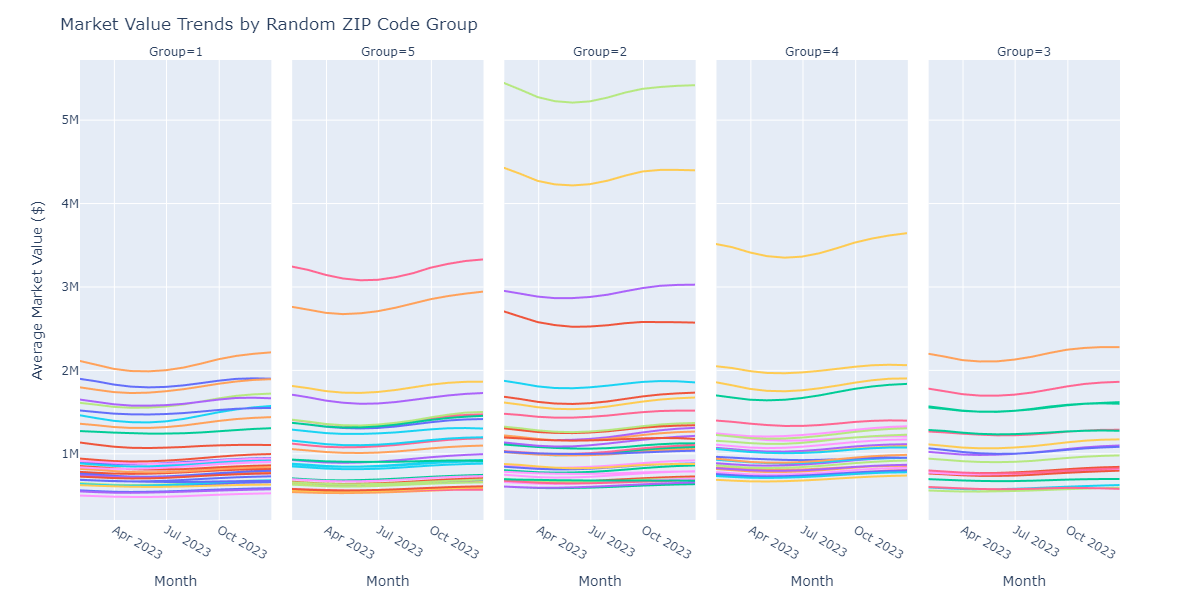

In [30]:
import plotly.express as px
from IPython.display import Image

marketval = df_housing[['RegionName', '2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31',
       '2023-06-30', '2023-07-31', '2023-08-31', '2023-09-30', '2023-10-31',
       '2023-11-30', '2023-12-31']].set_index('RegionName')


filled = pd.DataFrame(columns=marketval.index)
for i in marketval.index:
    filled[i] = marketval.loc[i].values
filled['Month'] = ['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31',
       '2023-06-30', '2023-07-31', '2023-08-31', '2023-09-30', '2023-10-31',
       '2023-11-30', '2023-12-31']
melted = filled.melt('Month', var_name='ZIP Code', value_name='Average Market Value ($)')

melted_unique = melted[melted['ZIP Code'].isin(df_merged['zip_code'])]


unique_zip_codes = melted_unique['ZIP Code'].unique()
zip_groups = pd.Series(np.random.randint(1, 6, size = len(unique_zip_codes)), index = unique_zip_codes)
melted_unique['Group'] = melted_unique['ZIP Code'].map(zip_groups)

fig = px.line(melted_unique, x='Month', y='Average Market Value ($)', 
              color='ZIP Code', line_group='ZIP Code', 
              facet_col='Group')

fig.update_layout(
    showlegend=False,  
    title="Market Value Trends by Random ZIP Code Group",
    height=600, width=1200,
)

Image(filename='markettrends.png')

### Section 2: Market Value of Houses and Total Crime Severity

Next, we decided to create a plot displaying the relationship between the frequency of crime and the market value of houses in each ZIP code area. We decided to focus on data from the year 2023, which we agreed was a good time into the post-COVID world to avoid possible confounds related to the pandemic.

C:\Users\jerem\AppData\Local\Temp\ipykernel_17368\2308097243.py:10: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`



<Axes: xlabel='crime_rating', ylabel='market_value'>

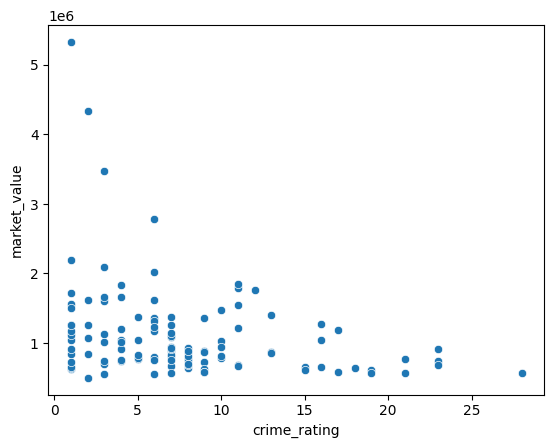

In [15]:
import seaborn as sns
marketval = pd.read_csv('dataupdated/marketval20-24.csv')
marketval = marketval[['RegionName', '2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31',
       '2023-06-30', '2023-07-31', '2023-08-31', '2023-09-30', '2023-10-31',
       '2023-11-30', '2023-12-31']].set_index('RegionName')

pivoted = pd.DataFrame(columns=marketval.index)
for i in marketval.index:
    pivoted[i] = marketval.loc[i].values
pivoted['Months'] = ['2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30', '2023-05-31',
       '2023-06-30', '2023-07-31', '2023-08-31', '2023-09-30', '2023-10-31',
       '2023-11-30', '2023-12-31']
pivoted = pivoted.set_index('Months')

marketmeans = pivoted.mean()
marketmeans = pd.DataFrame(marketmeans)
marketmeans = marketmeans.reset_index()
marketmeans = marketmeans.rename({0:'market_value'}, axis=1)

crimes2 = pd.read_csv('dataupdated/crimes_with_rating_zipcodes')
crimes2 = pd.DataFrame(crimes2.groupby('zip_code')['crime_rating'].count())
crimes2 = crimes2.reset_index()
new_mer2 = marketmeans.merge(crimes2, left_on='RegionName', right_on='zip_code')
new_mer2 = new_mer2.drop('zip_code', axis=1)
sns.scatterplot(new_mer2, x='crime_rating', y='market_value')

The resulting plot seems to show a weak, negative relationship between total crime rating and the average market value of houses in a certain area. There is significant clustering near the origin with no distinct trend.

### Section 3: Market Value of Houses and Total Crime Severity

We decided that we should also see whether the weighted crime counts are significant to the plotted relationship between crime and average market value of houses. In the next plot, we plotted the relationship between weighted crime counts and average market value of houses.

The frequency of crimes for this plot was weighted. Each crime was weighted by its "severity" in relation to all of the crime classifications designated by the LAPD in this dataset. Below is the code used to generate each ZIP code area's relation between total crime severity and average market value of houses.

<Axes: xlabel='crime_rating', ylabel='market_value'>

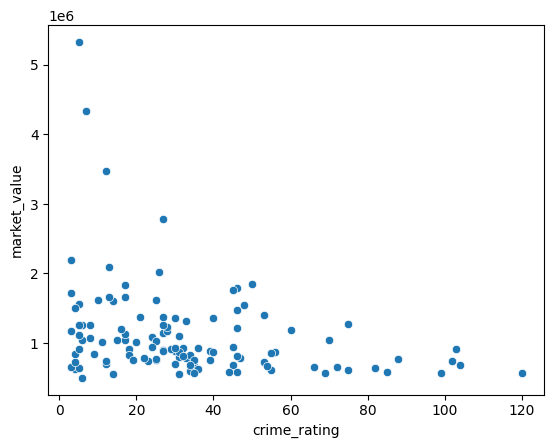

In [16]:
crimes = pd.read_csv('dataupdated/crimes_with_rating_zipcodes')
crimes = pd.DataFrame(crimes.groupby('zip_code')['crime_rating'].sum())

crimes = crimes.reset_index()

new_mer = marketmeans.merge(crimes, left_on='RegionName', right_on='zip_code')
new_mer = new_mer.drop('zip_code', axis=1)
sns.scatterplot(new_mer, x='crime_rating', y='market_value')

This plot also seems to show a weak, negative relationship between total crime rating and the average market value of houses in a certain area. There is significant clustering near the origin with no distinct trend.

## Data Analysis and Results

To see if there is a strong correlation bettween crime and average housing prices, we decided to make a linear regression model to predict average housing prices. To clarify, the predictive question we will be trying to answer is: Is total crimes and total crime severity in a zipcode area a good predictor for the local average house prices?

In [17]:
# Imports
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
log_transformer = FunctionTransformer(np.log)


We were given many differen regression models in this class, Sklearn LinearRegression, OLSRegression, and XGBoost regression. We decided on XGBoost, because the gradient boosting algorithm allowed for a more accurate linear regression when dealing with non-linear features, like the ones we posess: Total Crime and Total Crime Severity
To ensure we have a good model, some additional datacleaning and preprocessing was necessary:

- We removed any egregious outliers. We decided that outliers beyond 2.6 million were too extreme and would contribute negatively to the model. 
- Applied a log transformation because of the lack of a linear correlation between features total crimes and total crime severity when graphed against mean house price.
- Standardized the features to keep the features more readable and interpertible.
- Ran code to find out hyper parameters for our XGBoost model. Decided to use hyperparameters:
    -  n_estimators
    -  learning_rate
    -  max_depth

In [18]:
merged_outlier_removed = df_merged[df_merged['mean_market_value'] < 2600000]
total_crime = merged_outlier_removed.groupby('zip_code')[['crime_rating']].sum()
total_crime['num_crimes'] = merged_outlier_removed.groupby('zip_code')[['crime_rating']].count()
y_vals = merged_outlier_removed.set_index('zip_code')['mean_market_value'].sort_index().drop_duplicates()
X_train_rate, X_test_rate, y_train, y_test = train_test_split(total_crime, y_vals, test_size=0.2)

model = make_pipeline(
        log_transformer,
        StandardScaler(),
        xgb.XGBRegressor(objective='reg:squarederror')
)
param_grid = {
    'xgbregressor__n_estimators': [100, 200, 300, 400, 500], 
    'xgbregressor__learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2, 0.3],
    'xgbregressor__max_depth': [3, 5, 7, 9, 11, 15],
}

# grid_search = GridSearchCV(model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1)

# grid_search.fit(X_train_rate, y_train)

# best_params = grid_search.best_params_

# print(f"Best Hyperparameters: {best_params}")
# print(f"Best R² Score: {grid_search.best_score_}")

After cleaning the data and finding the hyper parameters, we can start to fit the model and start predicting. After the first fit, we notcied that there was a lot of variance in the $R^2$ scores, so we predicted with the model 1000 times and averaged out both $R^2$ and RMSE.

In [19]:
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

r2_score_lst = []
RMSE_score_lst = []

for _ in range(1000):
    X_train_rate, X_test_rate, y_train, y_test = train_test_split(total_crime, y_vals, test_size=0.2)


    model = make_pipeline(
        log_transformer,
        StandardScaler(),
        xgb.XGBRegressor(objective='reg:squarederror', learning_rate = 0.01, max_depth = 3, n_estimators = 100)
    )

    model.fit(X_train_rate, y_train)

    y_pred = model.predict(X_test_rate)
    r2_score_lst.append(r2_score(y_test, y_pred))
    RMSE_score_lst.append(root_mean_squared_error(y_test, y_pred))

print(f"R² score: {np.mean(r2_score_lst):.4f}")
print(f"RMSE: {np.mean(RMSE_score_lst):.4f}")

R² score: -0.0369
RMSE: 400979.2532


Since we have a lot of $R^2$ scores, we can plot them and see the distribution of our regression model's accuracy.

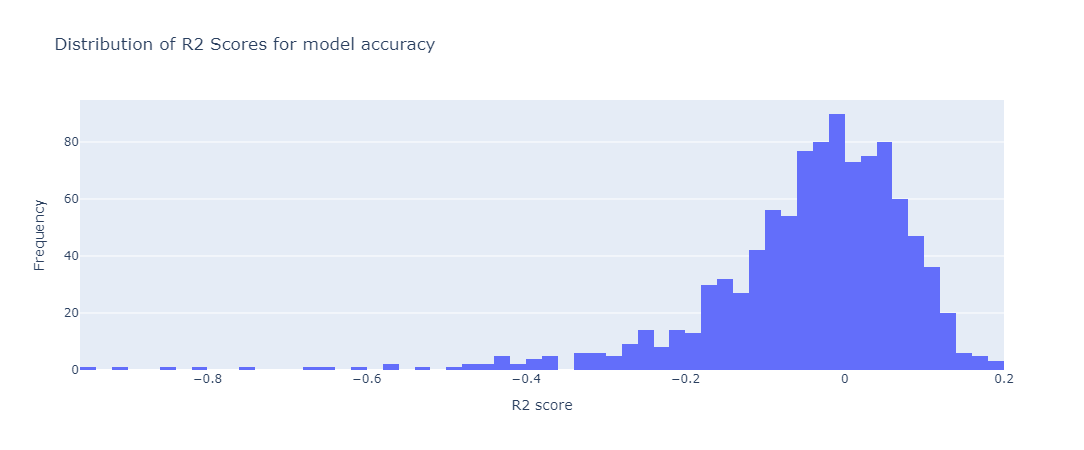

In [28]:
distribution = px.histogram(x = r2_score_lst, title = 'Distribution of R2 Scores for model accuracy')
distribution.update_layout(
    xaxis_title="R2 score",
    yaxis_title="Frequency"
)
Image(filename='r2dist.png') 

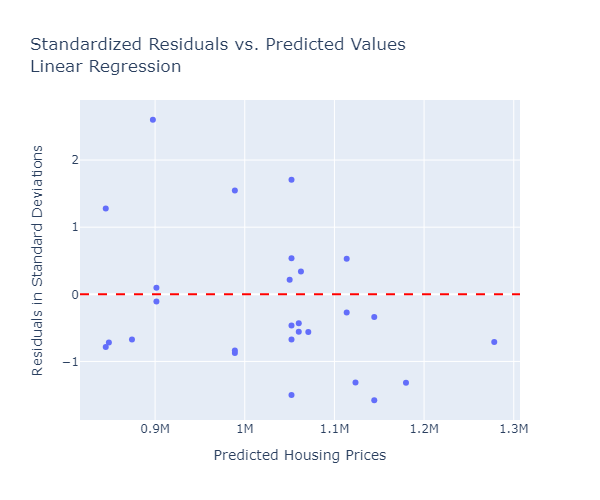

In [29]:
residuals = y_test - y_pred
std_residuals = np.std(residuals)
residuals_std = residuals / std_residuals
fig = px.scatter(x=y_pred, y=residuals_std, 
                 title="Standardized Residuals vs. Predicted Values<br>Linear Regression")
fig.add_hline(y=0, line_color='red', line_dash='dash')
fig.update_layout(
    xaxis_title="Predicted Housing Prices",
    yaxis_title="Residuals in Standard Deviations",
    width=600,
    height=500
)
Image(filename='linreg.png') 

From the extremely low scores for both the $R^2$ score and the RMSE, we can say that the model preforms extremely poorly. The residuals show no discernable pattern, which shows high variance. This could be from overfitting from the model, or bad features for prediction.

# Ethics & Privacy

Whenever considering a topic related to crime, there are always going to be concerns regarding privacy and especially regarding biases. The dataset we plan on using is taken from https://data.lacity.org/, an official website of Los Angeles city. The data collected is based on reported crime, so there is a lessened chance of systematic biases, even though it is likely still present. There is no real way to remove this bias, as it is nearly impossible to distinguish which cases might be due to bias. However, since there is no identifying information of any kind other than gender, our project should not be heavily influenced by bias.

However, many crimes get committed, but never get reported. It is possible we are missing a lot of data in terms of these unreported crimes, which could lead to our outcomes being inaccurate or biased. To try and counteract this, we would try and collect all the crime data and housing data possible to midigate the results of missing data.

We do acknowledge that our methodology regarding the ratings of crimes is biased. Even though we tried our best to follow existing law codes, there were still crimes that we had to make educated decisions as a group in order to produce the score. This subjectivity introduces the potential for ethical concerns, as our decisions may inadvertently reflect biases that influence the perceived severity of crimes. 

One factor to consider is whether or not the subjects of our data gave consent. While the potential offenders themselves did not give consent, it can be assumed that those who reported the potential offenders would know that their report would be recorded. Similarly, as all data is very close to anonymous and is publicly available, there should not be any concerns regarding data security. Additionally, if anyone contacts us about their data being used to fund our analysis, we would remove the data from our datasets and analysis.

For Data storage, we would keep our datasets under encryption and make sure the underlying data can't be accessed by people who weren't working on the project. This makes it so only our team members have access to the whole dataset, and not the public.
When we release our findings, we will make sure to not allow our findings to harm others due to unintended use. This means that if our findings and analysis were used to harm the public, we would implement a rollback process to disable our findings.

# Discusison and Conclusion

After compiling, cleaning, and merging our data, we structured our analysis around crime severity and frequency as predictors of housing prices in Los Angeles County in the year 2023. We aggregated crime data at the zip code level, ensuring consistency across different sources, and applied a log transformation to adjust for skewed data. Using XGBoost, we trained a regression model to see if crime statistics could predict differences in housing prices across zipcodes. To maximize the predictive power of our model, we After fitting and predicint with our model we noticed a large amount of variance in our $R^2$ score and RMSE. To account for this, we ran the model around 1000 times to see the variance in our model's $R^2$ score. However, our fitted model appeared to average with scores of $R^2$ of -0.0452 and RMSE of 396892.7317. Both of these scores indicate an extremely poor model.

Our results suggest that crime rates alone do not predict housing prices well, at least with the data and model we used. The consistently negative $R^2$ scores show that either the relationship between crime and housing costs is weak, not linear, or affected by missing information. This shows that total crime rate and total crime severity aren't good predictors. 

Since our model preformed poorly, this indicates that there are more important factors when appraising housing price rather than strictly crime. It is likely that factors like income, location, and neighborhood amenities affect home prices more than crime rates. Additionally, the way crime is reported and perceived may influence housing markets in ways that are not captured by raw crime statistics. Since the model did not produce useful results, alternative approaches to processing the data and selecting variables may be needed to better understand what drives housing prices.

In the end, our testing resulted in an inconclusive answer to our research question: How do factors such as the rate of crime or severity of crime influence the average market value of houses in Los Angeles county between 2020 to 2024? The short answer is, the impact of crime on housing prices seem negigible in the grand scheme of the real estate market.

Future work should incorporate more economic factors to provide a clearer picture of the influences on housing prices. Including variables such as median income, job availability, public transportation access, and school quality could help identify key predictors. Additionally, location likely plays a big role in housing prices. Further improvement of feature engineering, such as weighting crime data by type or distance to residential areas, could also improve predictions. While our analysis did not find a strong connection between crime and housing prices, it emphasizes the need to consider a broader set of features when modeling the price of housing.

Another caviate is that our severity rating is inherently biases, because we are rating crimes. While a crime like murder could unanimously be rated as a 10, most crimes could be rated differently and debated by others. We acknowledge this bias is present and can skew the results, such as our model being a poor predictor, which could be because of our biased crime ratings.



# Team Contributions

Elvin Chen contributed to the visualizations for the EDA analysis, the Linear Regression model (creating, cleaning and optimizing the model), the conclusion and generally contributing to the slideshow, and overall planning for the group.

Jeremy Cho contributed to data cleaning process, creating several visualizations for the data, the slideshow used in the group video, and leading the creation of the group video.

Nahaby Piceno contributed to the search for ideal datasets, the refinement of our research question and hypothesis. For the proposal she worked on data, team expectations and the project timeline sections. She was also present during refinement discussions for our data checkpoints and she worked on the video slides and helped with the script and recording.

Vincent Cho contributed to the data cleaning process, the slideshow used in the group video and the video itself, the ethics and privacy portions, and the conclusion.